## import libaries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score

## make dataset 

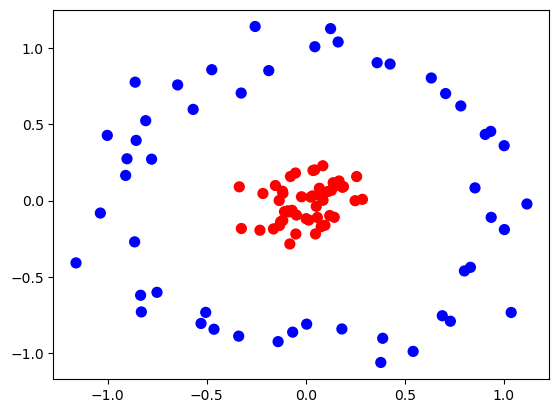

In [3]:
from sklearn.datasets._samples_generator import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')
plt.show()

## Train test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)



## SVC with linear kernel

In [ ]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

accuracy_score(y_test, y_pred)

0.6

C:\Users\sumit\AppData\Local\Temp\ipykernel_9188\2500001392.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


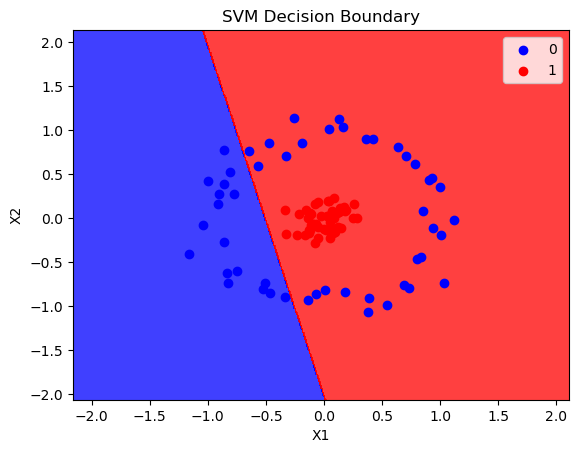

In [7]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

plot_decision_boundary(X, y, classifier)

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

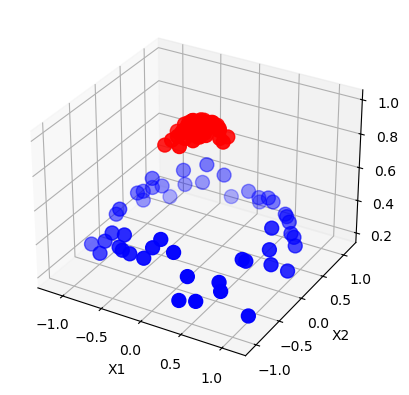

In [ ]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax
plot_3d_plot(X,y)

## SVC with rbg kernel

In [10]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

accuracy_score(y_test, y_pred)

1.0

C:\Users\sumit\AppData\Local\Temp\ipykernel_9188\2500001392.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


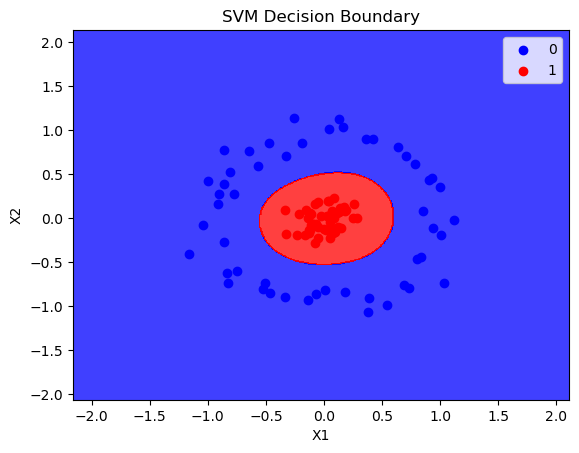

In [11]:
plot_decision_boundary(X,y,rbf_classifier)

## SVC with poly kernel

In [12]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

accuracy_score(y_test, y_pred)

1.0

C:\Users\sumit\AppData\Local\Temp\ipykernel_9188\2500001392.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


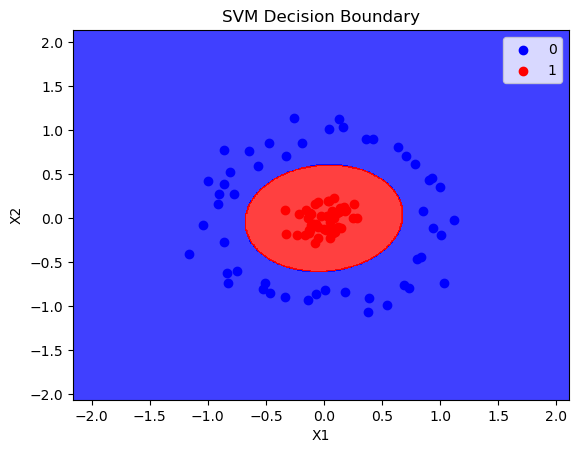

In [13]:
plot_decision_boundary(X, y, poly_classifier)

## Constraint optmisation
$\underset{x, y}{\operatorname{argmin}} \quad x^2y \quad \text{subject to} \quad x^2 + y^2 = 1
$

In [3]:
import plotly.graph_objects as go
import numpy as np

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
x, y = np.meshgrid(x, y)
z = x**2 * y

fig = go.Figure(data=[go.Surface(z=z, x=x, y=y)])
fig.update_layout(title='3D Plot of the function f(x, y) = x^2y', autosize=False,
                  width=800, height=600,
                  margin=dict(l=65, r=50, b=65, t=90))

fig.show()


In [2]:
import plotly.graph_objects as go
import numpy as np

# Create a set of points that lie on the circle
theta = np.linspace(0, 2*np.pi, 100)
x = np.cos(theta)
y = np.sin(theta)

# Create the plot
fig = go.Figure(data=go.Scatter(x=x, y=y, mode='lines'))

# Set the aspect ratio to equal so the circle doesn't look like an ellipse
fig.update_yaxes(
    scaleanchor = "x",
    scaleratio = 1,
)

fig.show()


In [11]:
import plotly.graph_objects as go
import numpy as np

# Create grid for the function
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
x, y = np.meshgrid(x, y)
z = x**2 * y

# Create a set of points that lie on the circle
theta = np.linspace(0, 2*np.pi, 100)
x_circle = np.cos(theta)
y_circle = np.sin(theta)
z_circle = x_circle**2 * y_circle

# Create the surface plot for the function
fig = go.Figure(data=[go.Surface(z=z, x=x, y=y, colorscale='Viridis', opacity=0.8)])

# Add the circle to the plot
fig.add_trace(go.Scatter3d(x=x_circle, y=y_circle, z=z_circle, mode='markers'))
fig.update_layout(title='3D Plot of the function f(x, y) = x^2y', autosize=False,
                  width=800, height=600,
                  margin=dict(l=65, r=50, b=65, t=90))

fig.show()

In [13]:
import plotly.graph_objects as go
import numpy as np

# Create grid for the function
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
x, y = np.meshgrid(x, y)
z = x**2 * y

# Create a set of points that lie on the circle
theta = np.linspace(0, 2*np.pi, 100)
x_circle = np.cos(theta)
y_circle = np.sin(theta)

# Create the contour plot for the function
fig = go.Figure(data=go.Contour(x=x[0,:], y=y[:,0], z=z))

# Add the circle to the plot
fig.add_trace(go.Scatter(x=x_circle, y=y_circle, mode='lines', line=dict(color='white')))

# Set aspect ratio
fig.update_layout(
    autosize=False,
    width=500,
    height=500,
    yaxis=dict(scaleanchor="x", scaleratio=1),
)

fig.show()

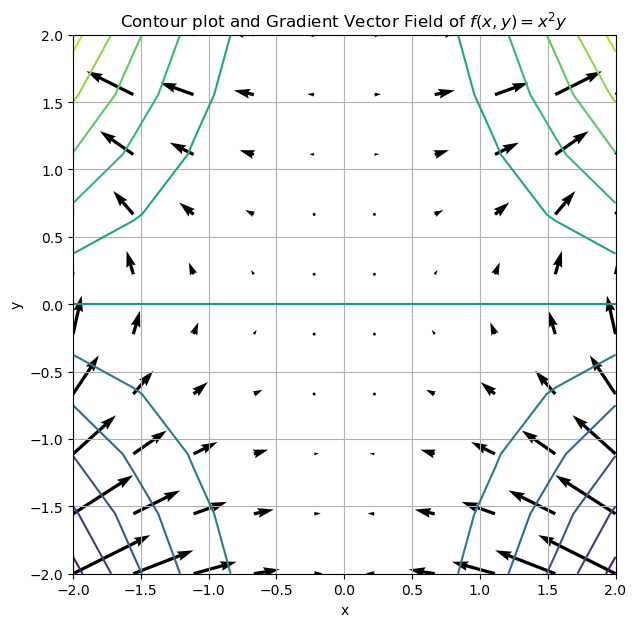

In [12]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 10)
y = np.linspace(-2, 2, 10)

X, Y = np.meshgrid(x, y)

# Compute the function values
Z = X**2 * Y

# Compute the gradient
U = 2*X*Y
V = X**2

plt.figure(figsize=(7, 7))

# Draw the contour plot
plt.contour(X, Y, Z, levels=10, cmap='viridis')

# Draw the gradient vector field
plt.quiver(X, Y, U, V)

plt.title('Contour plot and Gradient Vector Field of $f(x, y) = x^2y$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

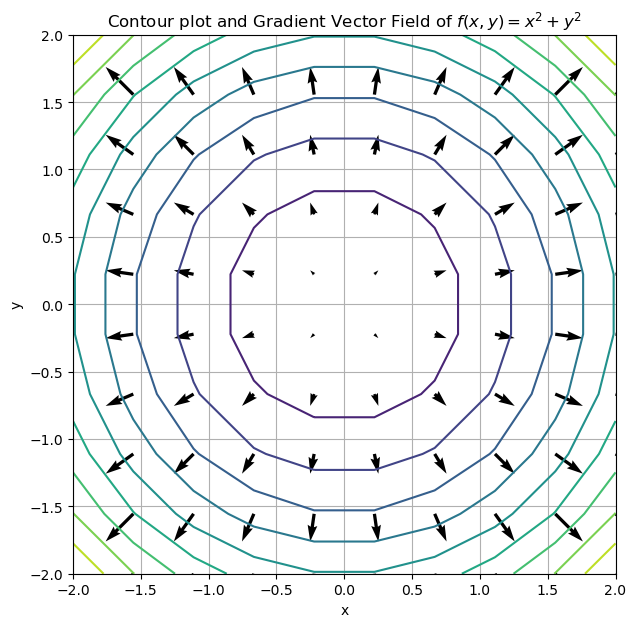

In [14]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 10)
y = np.linspace(-2, 2, 10)

X, Y = np.meshgrid(x, y)

# Compute the function values
Z = X**2 + Y**2

# Compute the gradient
U = 2*X
V = 2*Y

plt.figure(figsize=(7, 7))

# Draw the contour plot
plt.contour(X, Y, Z, levels=10, cmap='viridis')

# Draw the gradient vector field
plt.quiver(X, Y, U, V)

plt.title('Contour plot and Gradient Vector Field of $f(x, y) = x^2 + y^2$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()